# scFormer example notebook (simulate data)

This notebook runs **scFormer** on a single simulated dataset folder and writes **all outputs** into the same folder.

## Paths (updated per your request)

- **Input data folder**: `data/example/prob0.50_loc0.70_scale0.40`
  - Must contain:
    - `filtered_counts.csv`
    - `cell_metadata.csv`
- **Output folder**: `data/example/prob0.50_loc0.70_scale0.40/output`
  - The notebook will save:
    - `node_model.pth` (trained model)
    - `pred.npy`, `cell_embedding.npy`, `Node_Ids.npy`
    - `umap_results.pdf`
    - `metrics.csv` (F1, precision, recall)
    - `adata_train.h5ad` (cached AnnData for reproducibility/debugging)

> Recommendation: run this notebook from your repository root (the folder that contains `data/` and `scformer/`) so relative paths work reliably.


## How to run

1. Execute cells from top to bottom.
2. For a quick smoke test, reduce `EPOCHS` (for example 10 or 20).
3. If `import scformer` fails, the notebook will automatically append the current working directory to `sys.path` and retry (works when running from repo root).


## Troubleshooting

- **`filtered_counts.csv` or `cell_metadata.csv` not found**
  - Verify `DATA_DIR` points to `data/example/prob0.50_loc0.70_scale0.40`
- **Cannot import `scformer`**
  - Run the notebook from your repository root
  - Or install the project in editable mode (for example `pip install -e .`)
- **Out of memory / slow**
  - Reduce `EPOCHS`
  - Test on CPU first, then switch to GPU


In [3]:
# ===== 0. Imports and project path setup =====
import os
import sys
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import torch
from scipy.sparse import csr_matrix
from sklearn.metrics import f1_score, precision_score, recall_score
from torch.backends import cudnn

warnings.filterwarnings("ignore")

# --- Import local project modules (scformer) ---
# Notebook is located at: <repo_root>/Tutorial/*.ipynb
# and `scformer/` is a sibling of `Tutorial/`.
# So repo root = parent directory of the current working directory (when launched from Tutorial).
try:
    from scformer.model import *      # noqa: F401,F403
    from scformer.utils import *    # noqa: F401,F403
    print("✅ Imported scformer successfully.")
except Exception:
    print("⚠️ Direct import failed. Adding repo root to sys.path and retrying...")

    # Assume current working dir is <repo_root>/Tutorial (common when opening the notebook there)
    repo_root = Path.cwd().resolve().parent
    sys.path.insert(0, str(repo_root))

    from scformer.model import *      # noqa: F401,F403
    from scformer.utils import *    # noqa: F401,F403
    print("✅ Imported scformer successfully (via sys.path).")

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())


⚠️ Direct import failed. Adding repo root to sys.path and retrying...
✅ Imported scformer successfully (via sys.path).
Torch version: 2.1.0+cu118
CUDA available: True


In [4]:

# ===== 1. Global seed (reproducibility) =====
def set_global_seed(seed: int = 0) -> None:
    '''Set global random seed for reproducibility.'''
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    cudnn.deterministic = True
    cudnn.benchmark = False

set_global_seed(0)


In [5]:

# ===== 2. Data loading utilities =====
def read_single_cell_data(data_dir: str) -> sc.AnnData:
    '''
    Read simulated single cell data from:
      - filtered_counts.csv
      - cell_metadata.csv

    Expected format (consistent with your original script):
      - filtered_counts.csv: rows are genes, columns are cells
      - cell_metadata.csv: contains a column named 'Group' (ground truth label per cell)

    Returns
    -------
    AnnData
      - X: (cells x genes)
      - obs['Group']: ground truth group label
    '''
    data_dir = Path(data_dir)
    counts_path = data_dir / "filtered_counts.csv"
    meta_path = data_dir / "cell_metadata.csv"

    if not counts_path.exists():
        raise FileNotFoundError(f"Missing file: {counts_path}")
    if not meta_path.exists():
        raise FileNotFoundError(f"Missing file: {meta_path}")

    counts = pd.read_csv(counts_path, index_col=0)
    metadata = pd.read_csv(meta_path)

    if "Group" not in metadata.columns:
        raise ValueError("cell_metadata.csv must contain a 'Group' column.")

    # Transpose so AnnData X is (cells x genes)
    adata = sc.AnnData(counts.T)
    adata.obs["Group"] = metadata["Group"].values
    return adata


def prepare_output_dir(output_path: str) -> None:
    '''Create output directory if it does not exist.'''
    Path(output_path).mkdir(parents=True, exist_ok=True)


In [9]:

# ===== 3. Paths and training hyperparameters =====
# Input folder (your copied parameter folder)
DATA_DIR = Path("../data/example/prob0.50_loc0.70_scale0.40")

# Output folder (write everything under DATA_DIR/output)
OUTPUT_DIR = DATA_DIR / "output"
prepare_output_dir(str(OUTPUT_DIR))

# Training hyperparameters (adjust as needed)
CELL_SIZE = 30
N_HIDDEN = 104
N_HEADS = 8
N_LAYERS = 3
LEARNING_RATE = 5e-4
WEIGHT_DECAY = 0.1
EPOCHS = 100  # For a quick test, try 10 or 20

print("DATA_DIR  :", DATA_DIR.resolve())
print("OUTPUT_DIR:", OUTPUT_DIR.resolve())


DATA_DIR  : C:\code\SpatialTransformer\data\example\prob0.50_loc0.70_scale0.40
OUTPUT_DIR: C:\code\SpatialTransformer\data\example\prob0.50_loc0.70_scale0.40\output


In [10]:

# ===== 4. Training function =====
def train_model(
    adata: sc.AnnData,
    output_dir: str,
    cell_size: int = 30,
    n_hidden: int = 104,
    n_heads: int = 8,
    n_layers: int = 3,
    learning_rate: float = 0.0005,
    weight_decay: float = 0.1,
    epochs: int = 100,
) -> None:
    '''
    Train scFormer and save outputs into output_dir.

    Files created:
      - node_model.pth
      - Node_Ids.npy
      - pred.npy
      - cell_embedding.npy
      - graph_preprocess/ (graph preprocessing cache)
    '''
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    # scFormer expects a sparse matrix
    adata.X = csr_matrix(adata.X)

    # rna_matrix shape used by original pipeline: (genes x cells)
    rna_matrix = adata.X.T

    # Initial clustering labels
    initial_labels = initial_clustering(rna_matrix)
    initial_labels = [int(x) for x in initial_labels]

    # Graph preprocessing (subgraph indices, node ids, etc.)
    indices, node_ids, _ = batch_select_whole(
        rna_matrix,
        cell_size=cell_size,
        save_path=str(output_dir / "graph_preprocess"),
    )

    # Device selection
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Using device:", device)

    # Build model
    model = NDR_2(
        rna_matrix,
        indices,
        initial_labels,
        n_hid=n_hidden,
        n_heads=n_heads,
        n_layers=n_layers,
        labsm=0.1,
        lr=learning_rate,
        wd=weight_decay,
        device=device,
        num_types=2,
        num_relations=2,
        epochs=epochs,
    )

    # Train
    gnn, cell_emb, gene_emb, h = model.train_model(n_batch=len(indices))

    # Save model weights
    model.save_model(str(output_dir / "node_model.pth"))

    # Predict
    results = pred(rna_matrix, gnn=gnn, indices=indices, device=device)

    # Save numpy outputs
    np.save(output_dir / "Node_Ids.npy", node_ids)
    np.save(output_dir / "pred.npy", results["pred_label"])
    np.save(output_dir / "cell_embedding.npy", results["cell_embedding"])

    print("✅ Training finished. Outputs saved to:", output_dir.resolve())


In [11]:

# ===== 5. Run training (and cache AnnData) =====
adata = read_single_cell_data(str(DATA_DIR))
print(adata)

# Cache AnnData for reproducibility / debugging
adata_path = OUTPUT_DIR / "adata_train.h5ad"
adata.write(adata_path)
print("Saved:", adata_path.resolve())

# Train model
train_model(
    adata=adata,
    output_dir=str(OUTPUT_DIR),
    cell_size=CELL_SIZE,
    n_hidden=N_HIDDEN,
    n_heads=N_HEADS,
    n_layers=N_LAYERS,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    epochs=EPOCHS,
)


AnnData object with n_obs × n_vars = 2500 × 4211
    obs: 'Group'
Saved: C:\code\SpatialTransformer\data\example\prob0.50_loc0.70_scale0.40\output\adata_train.h5ad
	When the number of cells is less than or equal to 500, it is recommended to set the resolution value to 0.2.
	When the number of cells is within the range of 500 to 5000, the resolution value should be set to 0.5.
	When the number of cells is greater than 5000, the resolution value should be set to 0.8.
正在将数据划分为批次并进行并行处理。请稍候...


处理批次: 100%|██████████| 84/84 [00:24<00:00,  3.44it/s]


Using device: cuda
The training process for the NodeDimensionReduction model has started. Please wait.


Epochs: 100%|██████████| 100/100 [15:26<00:00,  9.27s/it]


The training for the NodeDimensionReduction model has been completed.


Prediction Batches: 100%|██████████| 84/84 [00:06<00:00, 12.42it/s]

✅ Training finished. Outputs saved to: C:\code\SpatialTransformer\data\example\prob0.50_loc0.70_scale0.40\output


In [15]:

# ===== 6. Result analysis: rare vs non-rare + UMAP visualization =====
def analyze_results(adata: sc.AnnData, output_dir: str) -> dict:
    '''
    Load saved predictions and embeddings, then:

    1) Map predicted cluster labels back to cells
    2) Define "true rare" based on Group proportion < 0.05
    3) Define "pred rare" based on predicted cluster proportion < 0.045
    4) Compute neighbors and UMAP using learned cell embeddings
    5) Save the UMAP figure
    6) Compute F1, precision, recall for rare detection

    Returns
    -------
    dict: {f1, precision, recall}
    '''
    output_dir = Path(output_dir)
    node_ids = np.load(output_dir / "Node_Ids.npy")
    pred_labels = np.load(output_dir / "pred.npy")
    cell_emb = np.load(output_dir / "cell_embedding.npy")

    # Align by node id order
    pred_df = pd.DataFrame(pred_labels, index=node_ids).sort_index()
    adata.obs["pre"] = pred_df.values
    adata.obs["pre"] = adata.obs["pre"].astype("category")

    emb_df = pd.DataFrame(cell_emb, index=node_ids).sort_index()
    adata.obsm["cell_emb"] = emb_df.values

    # True rare: Group frequency < 5%
    group_props = adata.obs["Group"].value_counts(normalize=True)
    rare_groups = group_props[group_props < 0.05].index
    adata.obs["true_rare"] = adata.obs["Group"].isin(rare_groups).map(
        {True: "rare", False: "non-rare"}
    )

    # Pred rare: predicted cluster frequency < 4.5%
    cluster_props = adata.obs["pre"].value_counts(normalize=True)
    rare_clusters = cluster_props[cluster_props < 0.045].index
    adata.obs["pred_rare"] = adata.obs["pre"].isin(rare_clusters).map(
        {True: "rare", False: "non-rare"}
    )

    # UMAP based on learned embedding
    sc.pp.neighbors(adata, use_rep="cell_emb")
    sc.tl.umap(adata)

    with plt.rc_context():
        fig = sc.pl.umap(
            adata,
            color=["pre", "Group", "true_rare", "pred_rare"],
            show=False,
            return_fig=True,
        )
        fig_path = output_dir / "umap_results.pdf"
        plt.savefig(fig_path, format="pdf", bbox_inches="tight")
        plt.show()
        plt.close()
        print("Saved:", fig_path.resolve())

    y_true = adata.obs["true_rare"].eq("rare").astype(int)
    y_pred = adata.obs["pred_rare"].eq("rare").astype(int)

    return {
        "f1": float(f1_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred)),
        "recall": float(recall_score(y_true, y_pred)),
    }


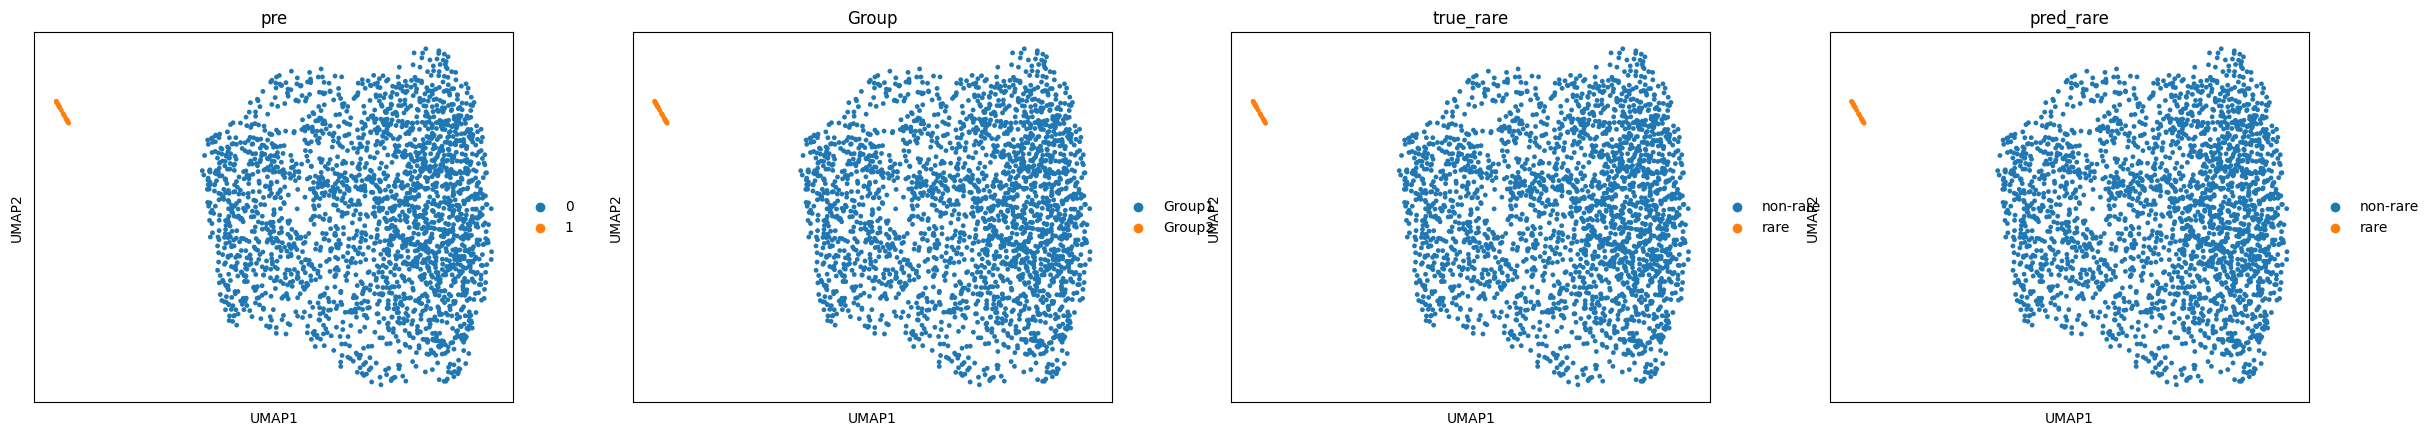

Saved: C:\code\SpatialTransformer\data\example\prob0.50_loc0.70_scale0.40\output\umap_results.pdf


{'f1': 1.0, 'precision': 1.0, 'recall': 1.0}

In [16]:

# ===== 7. Run analysis and save metrics =====
adata = sc.read_h5ad(OUTPUT_DIR / "adata_train.h5ad")
metrics = analyze_results(adata, str(OUTPUT_DIR))
metrics


In [17]:

# Save metrics to CSV
metrics_df = pd.DataFrame([metrics])
metrics_csv = OUTPUT_DIR / "metrics.csv"
metrics_df.to_csv(metrics_csv, index=False)
print("Saved:", metrics_csv.resolve())
metrics_df


Saved: C:\code\SpatialTransformer\data\example\prob0.50_loc0.70_scale0.40\output\metrics.csv


,f1,precision,recall
0,1.0,1.0,1.0
